# Aircraft Engine Predictive Maintenance Project : Remaining Useful Life (RUL) Prediction
## PROJECT OVERVIEW : 
---
### The project aims at developing a model to predict the number of flight cycles an aircraft turbofan engine has left before total degradation occurs

## BUSINESS UNDERSTANDING :
---
### For most aviation Operators, equipment downtime is exceptionally costly, and component failure can be catastrophic. Traditional maintenance strategies generally fall into two inefficient categories: 
* ### Reactive maintenance 
* ### Preventive maintenance 
### Airlines and M.R.O providers will benefit from this project, as predictive maintenance minimises maintenance costs while optimizing safety.

## DATASET UNDERSTANDING :
---
#### The dataset used for this project can be sourced [here](https://www.kaggle.com/datasets/fareselgohary003/nasa-cmapss-turbofan-engine-rul-dataset) from Kaggle

## Variables :
Each raw text log contains 26 columns mapping out the technical operational envelope of the turbofan:

- engine_id	- The unique engine number

- cycle - The operational flight cycle 

- setting_1 - Flight altitude (ft)

- setting_2 - Mach number (M)

- setting_3 - Throttle Lever Resolver Angle (TRA)

- Sensor 1: Total temperature at fan inlet (°R)

- Sensor 2: Total temperature at LPC (Low Pressure Compressor) outlet (°R)

- Sensor 3: Total temperature at HPC (High Pressure Compressor) outlet (°R)

- Sensor 4: Total temperature at LPT (Low Pressure Turbine) inlet (°R)

- Sensor 5: Total pressure at fan inlet (psia)

- Sensor 6: Fuel flow (Wf) (pps - pounds per second)

- Sensor 7: Total temperature at MIT (High Pressure Turbine) outlet (°R)

- Sensor 8: Total pressure at bypass duct (psia)

- Sensor 9: Physical fan speed (NRf) (rpm)

- Sensor 10: Physical core speed (NRc) (rpm)

- Sensor 11: Turbine exhaust gas temperature (°R)

- Sensor 12: Total pressure at HPC outlet (psia)

- Sensor 13: Total pressure at LPT outlet (psia)

- Sensor 14: Corrected fan speed (NfRstd) (rpm)

- Sensor 15: Bypass duct total temperature (°R)

- Sensor 16: Engine pressure ratio (P50/P2)

- Sensor 17: Static pressure at HPC outlet (Ps3) (psia)

- Sensor 18: Bleed enthalpy (h)

- Sensor 19: Demanded fan speed (Rfan) (rpm)

- Sensor 20: Corrected core speed (NcRstd) (rpm)

- Sensor 21: Demanded corrected fan speed (Rcore) (rpm)

### Target Variable : R.U.L .This is the number of remaining useful cycles that an engine has left before complete failure.
---






## 1. IMPORTING LIBRARIES AND LOADING DATASET

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sbs

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib



In [2]:
## defining column names, (also variables to be used) manually:
index_names = ['engine_id', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1,22)] # Generates sensor_1 to sensor_21
col_names = index_names + setting_names + sensor_names
all_sensors = [f'sensor_{i}' for i in range(1, 22)]

## Converting the .txt train train_df
# to .csv:
train_df = pd.read_csv('datasets/train_FD001.txt', sep=r'\s+', header=None,names = col_names)
train_df.to_csv('train_FD001.csv', index=False)
train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. FEATURE ENGINEERING (R.U.L)

* ### Creating the target column that is, the number of cycles an engine has left before failure 

In [3]:
## Engineering the Remaining Useful Life(R.U.L)column  --> target variable 
                                  
# 1. Finding the maximum cycle (the breakdown flight) for each unique engine
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

# 2 ..Merging the maximum cycle back into our main dataframe
train_df = pd.merge(train_df, max_cycle, on='engine_id')

# 3 .Calculating Remaining Useful Life (RUL)
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

## 4 dropping the max cycle column, no longer needed.
train_df_new = train_df.drop(columns=['max_cycle'])

In [4]:
train_df_new.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [5]:
train_df_new.to_csv('new_train_df.csv', index=False)

## 3. EXPLORATORY DATA ANALYSIS AND VISUALISATION

c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


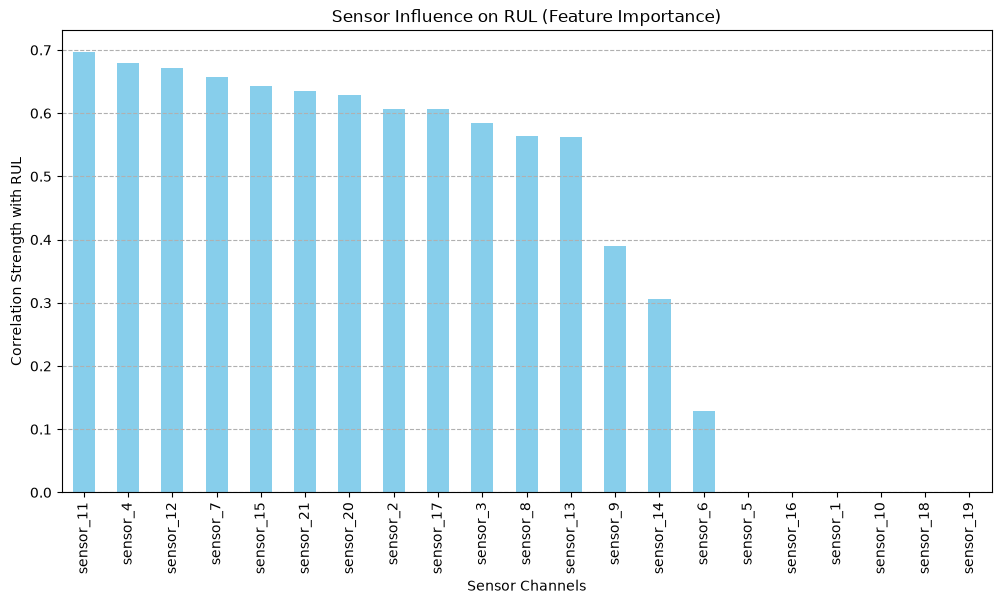

In [6]:

correlations = train_df[all_sensors].corrwith(train_df['RUL']).abs().sort_values(ascending=False)

### Plotting the influence of each sensor on RUL
plt.figure(figsize=(12, 6))
correlations.plot(kind='bar', color='skyblue')
plt.title('Sensor Influence on RUL (Feature Importance)')
plt.ylabel('Correlation Strength with RUL')
plt.xlabel('Sensor Channels')
plt.grid(axis='y', linestyle='--')
plt.show()

## Observation
---
* ### As seen from the barplot above, some sensors have highest influence on remaining useful lifetime, while others have least impact on R.U.L.
* ### This implies that some sensor readings provide meaningful data while others are irrelevant.

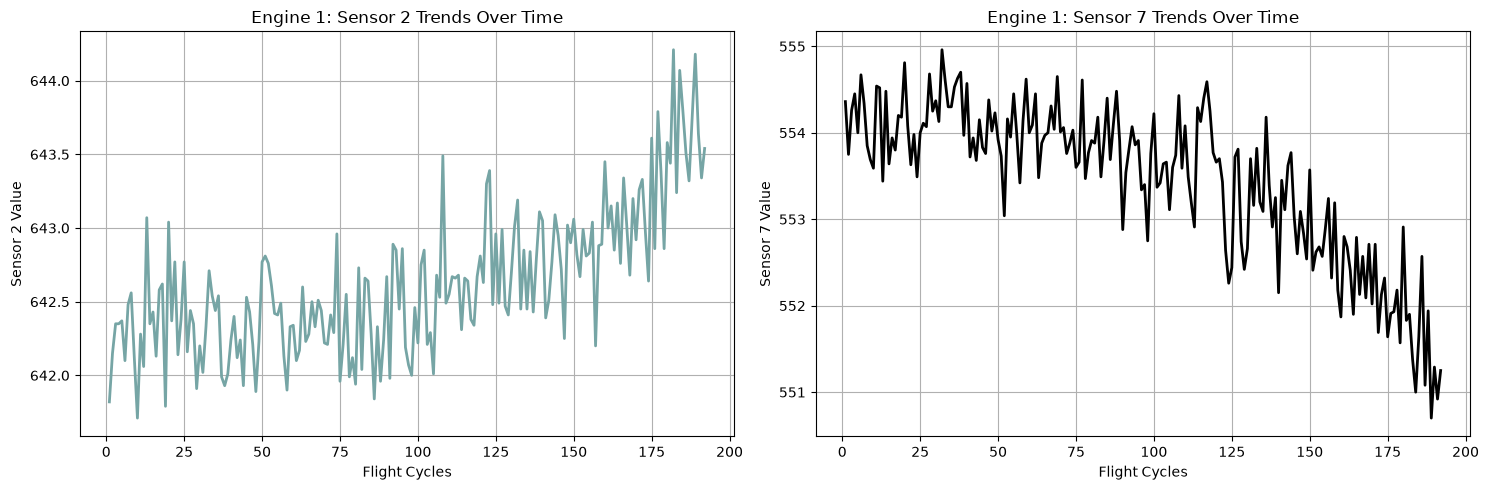

In [7]:
engine_1 = train_df[train_df['engine_id'] == 1] # looking at engine 1 only.

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) ## creating two subplots side by side

# 1 : A graph to show an example of a diagnostic (taken by sensor 2) that rises as engine failure nears
sbs.lineplot(ax=axes[0], data=engine_1, x='cycle', y='sensor_2', color='#76A5A5', linewidth=2)
axes[0].set_title('Engine 1: Sensor 2 Trends Over Time', fontsize=12)
axes[0].set_xlabel('Flight Cycles', fontsize=10)
axes[0].set_ylabel('Sensor 2 Value', fontsize=10)
axes[0].grid(True)

# 2 : An example of a diagnostic that falls as engine failure nears

sbs.lineplot(ax=axes[1], data=engine_1, x='cycle', y='sensor_7', color="#000000", linewidth=2)
axes[1].set_title('Engine 1: Sensor 7 Trends Over Time', fontsize=12)
axes[1].set_xlabel('Flight Cycles', fontsize=10)
axes[1].set_ylabel('Sensor 7 Value', fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Observations
---
* ### The readings for Sensor 2, which is total temperature at compressor outlet, increases as the engine continues degrading.
* ### The readings for Sensor 7, which is outlet temperature for the turbines, decreases as total breakdown nears.

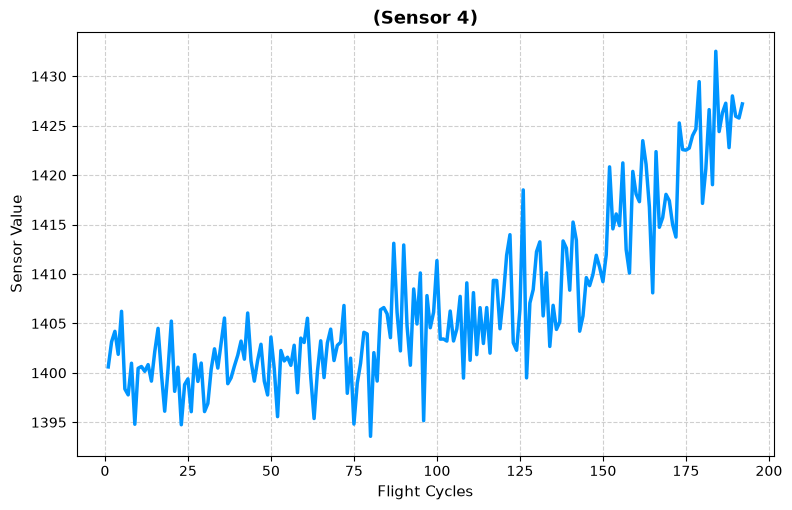

In [8]:
# A graph showing behavior of diagnostic recorded by sensor 4
plt.figure(figsize=(9,5.5))
sbs.lineplot(data=engine_1, x='cycle', y='sensor_4', color='#0095FF', linewidth=2.5)
plt.title('(Sensor 4)', fontsize=13, fontweight='bold')
plt.xlabel('Flight Cycles', fontsize=11)
plt.ylabel('Sensor Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Observation:
---
### The reading for sensor 4 (Total temperature at Low Pressure Turbine inlet) remains fairly constant for a while then starts increasing as more flight cycles are clocked.

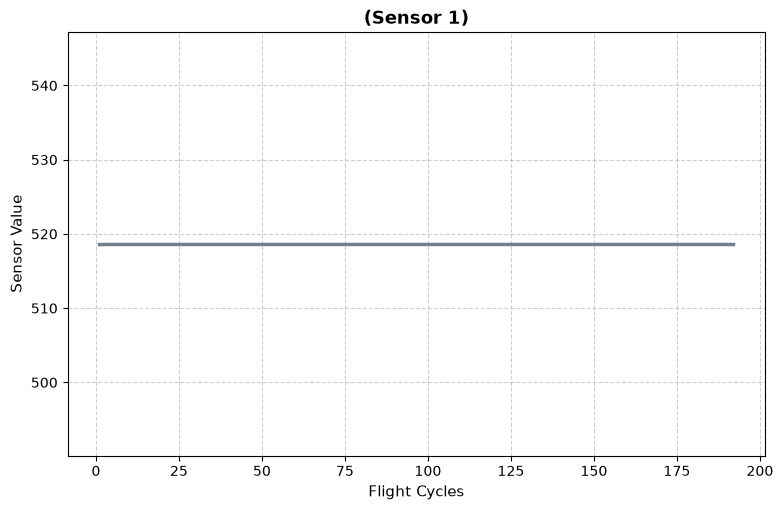

In [9]:
### Sensor 1 :
plt.figure(figsize=(9,5.5))
sbs.lineplot(data=engine_1, x='cycle', y='sensor_1', color='slategray', linewidth=2.5)
plt.title('(Sensor 1)', fontsize=13, fontweight='bold')
plt.xlabel('Flight Cycles', fontsize=11)
plt.ylabel('Sensor Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* ### For Sensor 1, readings remain compeletely constant this is total inlet temperature.

---
# Observations:
---
### As seen from the plots above different sensor values change in magnitude differently, as degradation nears :
* #### Some diagnostic values from certain sensors increase 
* #### Some diagnostic values from certain sensors reduce   
* #### Some remain compeletely flat. (This brings the need to ignore them as they are relevant)

---
## 4. DATA PREPROCESSING (Feature Selection and Normalisation)
---

In [10]:

# 1. Separating features and targets 
X = train_df[all_sensors]
y = train_df['RUL']

# 2. Splitting into Training and validating data
# This keeps the future data completely isolated
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Selection: Calculate 'features_to_drop' ONLY on X_train
features_to_drop = [s for s in all_sensors if X_train[s].std() == 0]
active_features = [s for s in all_sensors if s not in features_to_drop]

# Filter the datasets
X_train = X_train[active_features]
X_val = X_val[active_features]

# 4. Scaling: Fit ONLY on X_train
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply the SAME scaling parameters to X_val
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=active_features)
X_val = pd.DataFrame(X_val_scaled, columns=active_features)

X_train.head()



,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,0.381098,0.450900,0.404625,0.0,1.0,0.492754,0.384615,0.143408,0.0,0.341317,0.605544,0.338235,0.171225,0.409773,0.0,0.500000,0.565891,0.611907
1,0.301829,0.517658,0.382343,0.0,1.0,0.716586,0.153846,0.255766,0.0,0.335329,0.867804,0.220588,0.283517,0.215083,0.0,0.166667,0.542636,0.607273
2,0.353659,0.189337,0.336259,0.0,1.0,0.557166,0.169231,0.116845,0.0,0.185629,0.665245,0.338235,0.198627,0.310119,0.0,0.416667,0.658915,0.529627
3,0.463415,0.263841,0.383187,0.0,1.0,0.714976,0.184615,0.160459,0.0,0.281437,0.748401,0.176471,0.226442,0.370912,0.0,0.333333,0.604651,0.764252
4,0.439024,0.369788,0.387407,0.0,1.0,0.507246,0.400000,0.112896,0.0,0.407186,0.594883,0.411765,0.154557,0.379377,0.0,0.416667,0.488372,0.524993


## 5. MODEL TRAINING AND EVALUATION.

In [11]:
## Initialising models:

baseline_model = LinearRegression() # this is my bench mark.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.03, random_state=42, max_depth= 5,n_jobs = -1)

 ## Training models:
baseline_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)




,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
### Evaluating models on validation data
models = {
    "Linear Regression": baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


for name, model in models.items():
    # Make predictions on the validation sensors
    predictions = model.predict(X_val)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))

    
    print(f"...... {name} Performance ......")
    print(f"Mean Absolute Error (MAE): {mae:.2f} cycles")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cycles")
    print("-" * 40)





...... Linear Regression Performance ......
Mean Absolute Error (MAE): 34.04 cycles
Root Mean Squared Error (RMSE): 44.32 cycles
----------------------------------------
...... Random Forest Performance ......
Mean Absolute Error (MAE): 29.51 cycles
Root Mean Squared Error (RMSE): 41.34 cycles
----------------------------------------
...... XGBoost Performance ......
Mean Absolute Error (MAE): 29.49 cycles
Root Mean Squared Error (RMSE): 41.08 cycles
----------------------------------------


* ### Mean Absolute Error : This is the average prediction error. On any given flight, it tells us how many cycles away from the actual flight cycles remaining, the prediction is.
* ### Random Mean Squared Error : This is our "Worst-Case Scenario" metric, the maximum possible prediction error the model can make.

# Observations:
---

* ### It is noticeable that the XG_Boost model had the least Mean Squared error and Random Mean Squared Error, meaning it has the least errors in terms of predicting how many cycles an engine has left before it completely breaks down.

## 6. TESTING MODELS ON UNSEEN DATA (Unbiased Testing)

In [13]:
# 1. Loading the test data.
test_df = pd.read_csv('datasets/test_FD001.txt', sep=r'\s+', header=None, names = col_names)
true_rul = pd.read_csv('datasets/RUL_FD001.txt', sep=r'\s+', header=None, names=['true_RUL'])

In [14]:

# 2. PREPROCESSING THE TEST DATA

# We only care about the LATEST flight recorded for each engine in the test set
test_latest_flights = test_df.groupby('engine_id').last().reset_index()

# Extracting only the active, healthy sensor columns kept during Step 4
X_test_raw = test_latest_flights[active_features]

# Use the EXACT SAME scaler fitted on training data 
X_test_scaled = scaler.transform(X_test_raw)
X_test_final = pd.DataFrame(X_test_scaled, columns=active_features)

# Extract our ground truth target column (NASA's answers)
y_test = true_rul['true_RUL']


# 3. EVALUATING THE TRAINED MODELS ON TRUE UNSEEN DATA(test data)


# Defining function for universal accuracy metric
def calculate_universal_accuracy(y_test, test_predictions, test_df, mae):
    ## The total number of cycles for each engine:
    total_cycles_per_engine = test_df.groupby('engine_id')['cycle'].max()
    
    # Number of cycles per engine on average:
    avg_total_cycles = total_cycles_per_engine.mean()
    
    # Calculating percentage accuracy using the specific model's MAE:
    relative_accuracy = 100 - (mae / avg_total_cycles) * 100
    return relative_accuracy


print(" Final Scores on Unseen Test Data: ")

for name, model in models.items():
    # 1. Predict the remaining flights for the active test engines (FIXED: Moved inside loop)
    test_predictions = model.predict(X_test_final)
    
    # 2. Calculate final performance metrics against NASA's answer key
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    
    # 3. Calculate unique percentage accuracy for THIS model (FIXED: Passed test_mae)
    acc = calculate_universal_accuracy(y_test, test_predictions, test_df, test_mae)

    # 4. Print clean stakeholder-friendly output
    print(f"[{name}]")
    print(f"  \nOn average the model misses the final cycle by : {test_mae:.2f} cycles")
    print(f"  \nOn the highest margin of error, the model misses by : {test_rmse:.2f} cycles")
    print(f"  \nThe model accurately predicts an engine's remaining useful life : {acc:.2f}% of the time")
    print("-" * 55)

 Final Scores on Unseen Test Data: 
[Linear Regression]
  
On average the model misses the final cycle by : 25.65 cycles
  
On the highest margin of error, the model misses by : 32.17 cycles
  
The model accurately predicts an engine's remaining useful life : 80.41% of the time
-------------------------------------------------------
[Random Forest]
  
On average the model misses the final cycle by : 24.23 cycles
  
On the highest margin of error, the model misses by : 33.11 cycles
  
The model accurately predicts an engine's remaining useful life : 81.50% of the time
-------------------------------------------------------
[XGBoost]
  
On average the model misses the final cycle by : 23.45 cycles
  
On the highest margin of error, the model misses by : 31.91 cycles
  
The model accurately predicts an engine's remaining useful life : 82.10% of the time
-------------------------------------------------------


# EXPORTATION AND DEPLOYMENT.

In [15]:
# --- Exporting for Streamlit Deployment ---
# Save the model and the scaler so the App can "re-load" them
joblib.dump(xgb_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save the list of features so the app knows the exact input order
joblib.dump(active_features, 'features.pkl')


['features.pkl']

---
# Conclusion
---
* ### This project developed and evaluated machine learning models for predicting the Remaining Useful Life (RUL) of aircraft engines using the NASA CMAPSS dataset. The objective was to determine how many operating cycles an engine has left before failure, enabling maintenance teams to make informed decisions before critical breakdowns occur.

* ### The analysis showed that sensor data contains meaningful patterns related to engine degradation, allowing machine learning models to estimate RUL with reasonable accuracy. Multiple models were trained and compared, ranging from simple linear models to more advanced ensemble methods, demonstrating that machine learning can effectively support predictive maintenance strategies.

* ### By predicting engine health in advance, airlines and maintenance organizations can move away from reactive maintenance practices and adopt data-driven maintenance schedules. This can lead to reduced downtime, improved operational efficiency, enhanced safety, and lower maintenance costs.

### **Overall, the project demonstrates that predictive maintenance powered by machine learning has significant potential to improve reliability and decision-making in the aviation industry.**



---
# Recommendations
---
- ### Based on the findings of this study, the following recommendations are proposed:

*  #### 1. Airlines and MRO'S should replace fixed, 150-cycle overhaul rules (for example) with dynamic inspections triggered the moment the model flags an asset's RUL dropping below 30 cycles.

*  #### 2. Airlines and M.R.O’s should invest in this project for further proper development of the app and integration of aircraft manuals data, for ease in pinpointing maintenance procedures, rather than maintenance engineers scrolling through entire manuals.


* #### 3. Streamline Parts Inventory: Use the model’s RUL lead time to automate supply-chain logistics—pre-ordering replacement parts and scheduling hangar labor before terminal wear occurs to minimize inventory storage costs.

* ####  4. To facilitate adoption by maintenance personnel, the trained model should be deployed as a lightweight Streamlit application. Instead of interacting with Python code, engineers can upload an engine's latest sensor readings or enter them manually to receive an instant Remaining Useful Life (RUL) prediction.
